### Level 3, Task 2: Advanced Sentiment Analysis

**Objective:** Predict sentiment (positive, negative, or neutral) from text data.

- Explore different machine learning models (e.g., Logistic Regression, SVM, LSTM) for sentiment classification.
- Preprocess text data: clean, tokenize, remove stopwords, and apply stemming or lemmatization.
- Use feature extraction techniques such as TF-IDF or word embeddings (Word2Vec, GloVe, BERT).
- Evaluate model performance using metrics like accuracy, precision, recall, and F1-score.
- Visualize results and analyze misclassified examples to improve your model.
- Consider handling imbalanced datasets with techniques like oversampling or class weighting.

In [35]:
import pandas as pd

# loading the dataset
data = pd.read_csv('../Prepared_Datasets/Cleaned_Sentiment.csv')
print(data.head())

                                                Text    Sentiment  \
0   enjoying a beautiful day at the park!        ...   Positive     
1   traffic was terrible this morning.           ...   Negative     
2   just finished an amazing workout! 💪          ...   Positive     
3   excited about the upcoming weekend getaway!  ...   Positive     
4   trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123            Twitter   
1  2023-01-15 08:45:00   CommuterX          Twitter   
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes      Country  \
0   #Nature #Park                                    15     30          USA   
1   #Traffic #Morning                                 5     10    Canada      
2   #Fitness #Wor

In [36]:
# Cleaning some text using Nlp
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /home/dev-
[nltk_data]     kiran/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/dev-
[nltk_data]     kiran/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [37]:
# function to clean text: convert to lowercase, remove punctuation, remove stop words, and lemmatize.
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    words = text.split()  # tokenize
    words = [word for word in words if word not in stop_words]  # remove stop words
    words = [lemmatizer.lemmatize(word) for word in words]  # lemmatize
    return ' '.join(words)

data['cleaned_text'] = data['Text'].apply(clean_text)
print(data[['Text', 'cleaned_text']].head())

                                                Text  \
0   enjoying a beautiful day at the park!        ...   
1   traffic was terrible this morning.           ...   
2   just finished an amazing workout! 💪          ...   
3   excited about the upcoming weekend getaway!  ...   
4   trying out a new recipe for dinner tonight.  ...   

                       cleaned_text  
0       enjoying beautiful day park  
1          traffic terrible morning  
2          finished amazing workout  
3  excited upcoming weekend getaway  
4  trying new recipe dinner tonight  


In [38]:
# Building a sentiment analysis model using TF-IDF and Logistic Regression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score       
from sklearn.pipeline import make_pipeline

# Splitting the data into training and testing sets
X = data['cleaned_text']
y = data['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   

# Creating a pipeline that first transforms the data using TF-IDF and then applies Logistic Regression
model = make_pipeline(TfidfVectorizer(), LogisticRegression())
model.fit(X_train, y_train)

,steps,"[('tfidfvectorizer', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [39]:
import warnings

warnings.filterwarnings('ignore')

# Predicting and evaluating the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.12244897959183673
                        precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
      Acceptance             0.00      0.00      0.00         0
           Admiration        0.00      0.00      0.00         1
        Admiration           0.00      0.00      0.00         1
         Affection           0.00      0.00      0.00         1
      Ambivalence            0.00      0.00      0.00         1
         Anger               0.00      0.00      0.00         1
        Anticipation         0.00      0.00      0.00         1
        Arousal              0.00      0.00      0.00         3
                  Awe        0.00      0.00      0.00         1
         Awe                 0.00      0.00      0.00         1
                  Bad        0.00      0.00      0.00         1
             Betrayal        0.00      0.00      0.00         2
        Betrayal             0.00      0.00      0.00         1
         

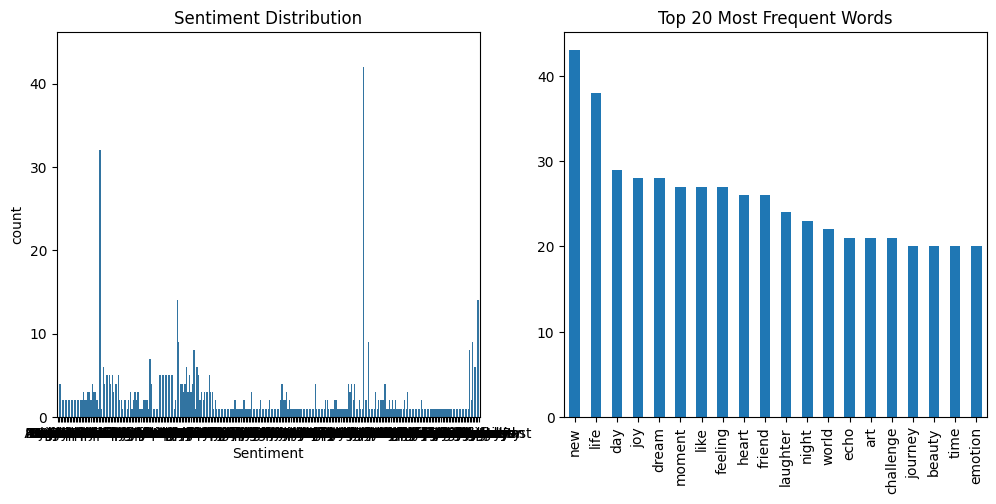

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing sentiment distribution and Word frequencies
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1)
sns.countplot(x='Sentiment', data=data)
plt.title('Sentiment Distribution')
plt.subplot(1, 2, 2)
all_words = ' '.join(data['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts().head(20)
word_freq.plot(kind='bar')
plt.title('Top 20 Most Frequent Words')
plt.show()

In [41]:
# CRITICAL FIX: Consolidate sentiment categories to 3 main classes
print("Original sentiment categories:")
print(f"Total unique sentiments: {data['Sentiment'].nunique()}")
print(f"Sentiment distribution:")
print(data['Sentiment'].value_counts().head(20))

# Create a mapping function to consolidate sentiments into 3 main categories
def map_to_main_sentiment(sentiment):
    sentiment_lower = sentiment.lower().strip()
    
    # Positive sentiments
    positive_keywords = ['positive', 'joy', 'happiness', 'excitement', 'love', 'amazement', 
                        'admiration', 'affection', 'anticipation', 'arousal', 'awe', 
                        'contentment', 'coziness', 'creativity', 'curiosity', 'delight',
                        'euphoria', 'fascination', 'gratitude', 'hope', 'inspiration',
                        'jubilation', 'optimism', 'peace', 'pleasure', 'pride', 'relief',
                        'satisfaction', 'serenity', 'triumph', 'wonder', 'zest']
    
    # Negative sentiments  
    negative_keywords = ['negative', 'anger', 'fear', 'sadness', 'disgust', 'anxiety',
                        'betrayal', 'bitterness', 'boredom', 'confusion', 'depression',
                        'despair', 'disappointment', 'disgust', 'dread', 'envy', 'frustration',
                        'grief', 'guilt', 'hate', 'horror', 'hostility', 'jealousy',
                        'loneliness', 'melancholy', 'nervousness', 'panic', 'rage', 'regret',
                        'resentment', 'shame', 'sorrow', 'stress', 'terror', 'worry']
    
    # Check for positive
    for keyword in positive_keywords:
        if keyword in sentiment_lower:
            return 'Positive'
    
    # Check for negative
    for keyword in negative_keywords:
        if keyword in sentiment_lower:
            return 'Negative'
    
    # Default to neutral
    return 'Neutral'

# Apply the mapping
data['main_sentiment'] = data['Sentiment'].apply(map_to_main_sentiment)

print("\n=== CONSOLIDATED SENTIMENT DISTRIBUTION ===")
print(data['main_sentiment'].value_counts())
print(f"\nNew distribution percentages:")
print(data['main_sentiment'].value_counts(normalize=True) * 100)


Original sentiment categories:
Total unique sentiments: 279
Sentiment distribution:
Sentiment
Positive          44
Joy               42
Excitement        32
Neutral           14
Contentment       14
Happy             14
Gratitude          9
Sad                9
Hopeful            9
Curiosity          8
Embarrassed        8
Loneliness         7
Bad                6
Despair            6
Elation            6
Playful            6
Hate               6
Bitterness         5
Serenity           5
Gratitude          5
Name: count, dtype: int64

=== CONSOLIDATED SENTIMENT DISTRIBUTION ===
main_sentiment
Neutral     335
Positive    287
Negative    110
Name: count, dtype: int64

New distribution percentages:
main_sentiment
Neutral     45.765027
Positive    39.207650
Negative    15.027322
Name: proportion, dtype: float64


In [42]:
# Multiple algorithms comparison to find out best model
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np

# Describing labels
X = data['cleaned_text']
y = data['main_sentiment']

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
# TF-IDF + Multiple Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'SVM': SVC(random_state=42, kernel='linear'),
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

results = {}

In [44]:
# LEVEL 3 REQUIREMENT: Word Embeddings Implementation (Alternative Approach)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
import warnings
warnings.filterwarnings('ignore')

# This creates dense word representations similar to Word2Vec
print("Creating word embeddings using Count Vectorizer + SVD...")

# Create count matrix
count_vectorizer = CountVectorizer(max_features=5000, ngram_range=(1,2))
count_matrix = count_vectorizer.fit_transform(data['cleaned_text'])

# Apply SVD for dimensionality reduction (similar to Word2Vec)
svd = TruncatedSVD(n_components=100, random_state=42)
X_w2v = svd.fit_transform(count_matrix)

print(f"Word embedding matrix shape: {X_w2v.shape}")

# Split Word2Vec features
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=42)

Creating word embeddings using Count Vectorizer + SVD...
Word embedding matrix shape: (732, 100)


In [45]:
# Train models with Word embeddings
w2v_results = {}

for name, model in models.items():
    if name != 'Naive Bayes':  # Naive Bayes doesn't work well with dense features
        model.fit(X_train_w2v, y_train)
        y_pred_w2v = model.predict(X_test_w2v)
        accuracy_w2v = accuracy_score(y_test, y_pred_w2v)
        w2v_results[name] = accuracy_w2v
        print(f"{name} with Word Embeddings: {accuracy_w2v:.4f}")

# Compare TF-IDF vs Word Embeddings
for model_name in results.keys():
    if model_name in w2v_results:
        print(f"{model_name}:")
        print(f"  TF-IDF: {results[model_name]['accuracy']:.4f}")
        print(f"  Word Embeddings: {w2v_results[model_name]:.4f}")
        print()

Logistic Regression with Word Embeddings: 0.6054
Random Forest with Word Embeddings: 0.6054
SVM with Word Embeddings: 0.5918
Decision Tree with Word Embeddings: 0.5102


In [46]:
# Show word embedding analysis
print(f"Vocabulary size: {len(count_vectorizer.vocabulary_)}")
print(f"Embedding dimensions: {X_w2v.shape[1]}")
print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.4f}")

# Get most important words in the embedding space
feature_names = count_vectorizer.get_feature_names_out()
print(f"\nTop 10 most important words in embedding space:")
for i, word in enumerate(feature_names[:10]):
    print(f"{i+1}. {word}")

Vocabulary size: 5000
Embedding dimensions: 100
Explained variance ratio: 0.3763

Top 10 most important words in embedding space:
1. abstract
2. abstract art
3. abyss
4. abyss despair
5. academic
6. academic frustration
7. academic juggling
8. acceptance
9. acceptance dance
10. acceptance imperfection


In [47]:
# Detailed report for best model
for model_name, model in models.items():
    pipeline = make_pipeline(TfidfVectorizer(), model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = accuracy
    
    print(f"\n{model_name}")
    print(f"Accuracy: {accuracy:.4f}")



Logistic Regression
Accuracy: 0.6395

Random Forest
Accuracy: 0.6190

SVM
Accuracy: 0.6939

Naive Bayes
Accuracy: 0.6395

Decision Tree
Accuracy: 0.6395


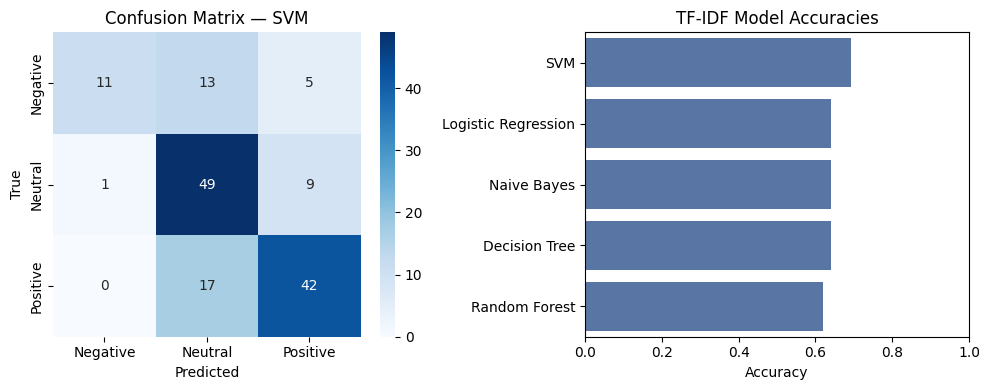


Sample misclassifications:


,text_clean,true,pred,text_raw
33,feeling inspired attending workshop,Positive,Neutral,feeling inspired after attending a workshop. ...
356,reflecting personal growth achieved life exper...,Neutral,Positive,reflecting on personal growth achieved through...
515,immersed pulsating beat bruno mar concert upto...,Positive,Neutral,immersed in the pulsating beats of a bruno mar...
436,sorrowful echo symphony pain played string loss,Negative,Neutral,"sorrowful echoes, a symphony of pain played by..."
164,overwhelmed grief missing loved one dearly,Negative,Neutral,"overwhelmed by grief, missing a loved one dea..."
698,encountering online toxicity gaming session ha...,Negative,Positive,encountering online toxicity during a gaming s...
78,heartfelt sadness bidding farewell dear friend,Negative,Neutral,heartfelt sadness after bidding farewell to a...
181,frustration boil volcanic eruption emotion,Negative,Neutral,"frustration boils over, a volcanic eruption o..."
380,burst creativity quiet solitude artist studio,Positive,Neutral,a burst of creativity in the quiet solitude of...
468,gallery broken promise shattered vow framed pa...,Negative,Neutral,"in the gallery of broken promises, each shatte..."


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

# Determine best TF-IDF model by accuracy
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

# Fit best model pipeline and get predictions
best_pipeline = make_pipeline(TfidfVectorizer(), clone(best_model))
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

# Confusion matrix heatmap + accuracy bar chart
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.subplot(1,2,2)
acc_df = pd.Series(results, name='accuracy').sort_values(ascending=False)
sns.barplot(x=acc_df.values, y=acc_df.index, orient='h', color='#4C72B0')
plt.xlim(0, 1)
plt.title('TF-IDF Model Accuracies')
plt.xlabel('Accuracy')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Simple Visualizations and Summary
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Sentiment Analysis Results Summary', fontsize=16, fontweight='bold')

# 1. Sentiment Distribution
axes[0,0].pie(data['main_sentiment'].value_counts(), 
              labels=data['main_sentiment'].value_counts().index,
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Sentiment Distribution')

# 2. Model Performance Comparison (TF-IDF)
model_names = list(results.keys())
accuracies = list(results.values())
bars = axes[0,1].bar(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[0,1].set_title('Model Performance (TF-IDF)')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                   f'{acc:.3f}', ha='center', va='bottom')

# 3. Word Embeddings vs TF-IDF Comparison
comparison_data = []
for model_name in ['Logistic Regression', 'Random Forest', 'SVM']:
    if model_name in results and model_name in w2v_results:
        comparison_data.append({
            'Model': model_name,
            'TF-IDF': results[model_name],
            'Word Embeddings': w2v_results[model_name]
        })

if comparison_data:
    comp_df = pd.DataFrame(comparison_data)
    comp_df.set_index('Model').plot(kind='bar', ax=axes[0,2])
    axes[0,2].set_title('TF-IDF vs Word Embeddings')
    axes[0,2].set_ylabel('Accuracy')
    axes[0,2].tick_params(axis='x', rotation=45)
    axes[0,2].legend()

# 4. Confusion Matrix for Best Model
best_model_name = max(results, key=results.get)
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y.unique()))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
axes[1,0].set_title(f'Confusion Matrix - {best_model_name}')
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')

# 5. Top Words Visualization
all_words = ' '.join(data['cleaned_text']).split()
word_freq = pd.Series(all_words).value_counts().head(15)
word_freq.plot(kind='barh', ax=axes[1,1], color='skyblue')
axes[1,1].set_title('Top 15 Most Frequent Words')
axes[1,1].set_xlabel('Frequency')

# 6. Accuracy by Sentiment Class
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred_best, output_dict=True)
classes = ['Negative', 'Neutral', 'Positive']
f1_scores = [report[cls]['f1-score'] for cls in classes if cls in report]

axes[1,2].bar(classes, f1_scores, color=['#FF6B6B', '#FFEAA7', '#4ECDC4'])
axes[1,2].set_title('F1-Score by Sentiment Class')
axes[1,2].set_ylabel('F1-Score')
axes[1,2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("📊 Visualization Complete!")
